In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

In [ ]:
df = pd.read_csv("/content/1_Daily_minimum_temps.csv")
df = df[['Temp']]

In [ ]:

df['Temp'] = df['Temp'].replace('?', np.nan)
df['Temp'] = pd.to_numeric(df['Temp'], errors='coerce')

In [ ]:
df = df.dropna()

In [ ]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(df.values)

In [ ]:
X = []
y = []

for i in range(30, len(scaled_data)):
    X.append(scaled_data[i-30:i, 0])
    y.append(scaled_data[i, 0])

X, y = np.array(X), np.array(y)

# Reshape for LSTM
X = np.reshape(X, (X.shape[0], X.shape[1], 1)) # (samples, timesteps, features)

In [ ]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [ ]:
model = Sequential()


model.add(LSTM(units=50, return_sequences=True, input_shape=(X.shape[1], 1)))
model.add(LSTM(units=50))

model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(optimizer='adam', loss='mean_squared_error')

In [ ]:
model.fit(X_train, y_train, epochs=10, batch_size=32)

Epoch 1/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - loss: 0.0220
Epoch 2/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0119
Epoch 3/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - loss: 0.0116
Epoch 4/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0114
Epoch 5/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0111
Epoch 6/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 0.0109
Epoch 7/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0103
Epoch 8/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 0.0100
Epoch 9/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.0095
Epoch 10/10
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.0093


In [ ]:
predictions = model.predict(X_test)

predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step


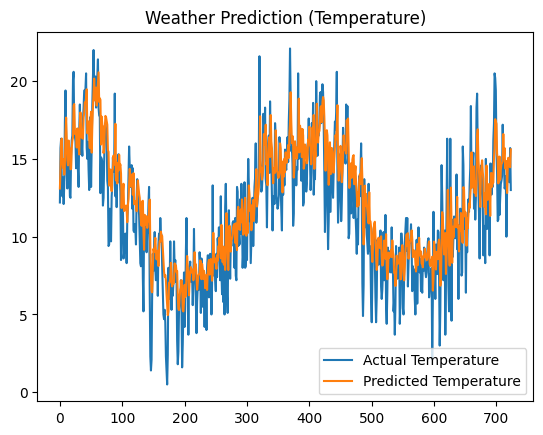

In [ ]:
plt.plot(y_test_actual, label="Actual Temperature")
plt.plot(predictions, label="Predicted Temperature")
plt.legend()
plt.title("Weather Prediction (Temperature)")
plt.show()

In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test_actual, predictions)
print("R2 Score:", r2)

R2 Score: 0.6661766156913573


In [ ]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test_actual, predictions)
print("MSE:", mse)

MSE: 5.610670120671781
